In [1]:
import os
import numpy as np
import skimage.io as io
from pycocotools import coco, mask as maskUtils
from PIL import Image
import torch
from torchvision import transforms
import cv2

# Load annotation files
rgbAnnFile = './aauRainSnow-rgb.json'
thermalAnnFile = './aauRainSnow-thermal.json'
rainSnowRgbGt = coco.COCO(rgbAnnFile)
rainSnowThermalGt = coco.COCO(thermalAnnFile)

def coco_ann_to_mask(ann, height, width):
    seg = ann.get('segmentation', None)
    if not seg:
        raise ValueError("Missing segmentation")
    if isinstance(seg, list):
        if len(seg) == 0:
            raise ValueError("Empty segmentation list")
        rles = maskUtils.frPyObjects(seg, height, width)
        rle = maskUtils.merge(rles)
    elif isinstance(seg, dict) and 'counts' in seg:
        rle = seg
    else:
        raise ValueError("Invalid segmentation format")
    return maskUtils.decode(rle)

def build_aau_dataset(rainSnowRgbGt, rainSnowThermalGt, target_size=(224, 224), max_images=2197):
    dataset = []

    tf_rgb = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    tf_thermal = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    for i in range(max_images):
        annIds = rainSnowRgbGt.getAnnIds(imgIds=[i])
        anns = rainSnowRgbGt.loadAnns(annIds)

        if not anns:
            continue

        rgb_info = rainSnowRgbGt.loadImgs([i])[0]
        thermal_info = rainSnowThermalGt.loadImgs([i])[0]
        thermal_anns = rainSnowThermalGt.loadAnns(annIds)

        try:
            rgb_img = io.imread('./' + rgb_info['file_name'])
            thermal_img = io.imread('./' + thermal_info['file_name'])
        except Exception as e:
            print(f"Error reading image {i}: {e}")
            continue

        height, width = rgb_img.shape[:2]
        combined_mask = np.zeros((height, width), dtype=np.uint8)

        for ann in anns:
            try:
                cat_id = ann['category_id']
                mask = coco_ann_to_mask(ann, height, width)
                combined_mask = np.maximum(combined_mask, mask * cat_id)
            except Exception as e:
                print(f"Skipping ann {ann.get('id')} in image {i}: {e}")

        if len(thermal_img.shape) == 3:
            thermal_img = cv2.cvtColor(thermal_img, cv2.COLOR_BGR2GRAY)

        try:
            rgb_tensor = tf_rgb(rgb_img)
            thermal_tensor = tf_thermal(thermal_img)
            mask_tensor = torch.from_numpy(np.array(
                transforms.Resize(target_size, interpolation=Image.NEAREST)(
                    Image.fromarray(combined_mask)
                )
            )).long()
        except Exception as e:
            print(f"Error transforming image {i}: {e}")
            continue

        dataset.append({
            'id': i,
            'file_name': rgb_info['file_name'],
            'rgb': rgb_tensor,
            'thermal': thermal_tensor,
            'mask': mask_tensor
        })

    print(f"Dataset built with {len(dataset)} samples.")
    return dataset


loading annotations into memory...
Done (t=0.28s)
creating index...
index created!
loading annotations into memory...
Done (t=0.42s)
creating index...
index created!


In [2]:
dataset = build_aau_dataset(rainSnowRgbGt, rainSnowThermalGt, target_size=(224, 224))

# Print the first few samples
for sample in dataset[:3]:
    print(f"\nID: {sample['id']}, File: {sample['file_name']}")
    print(f"RGB: {sample['rgb'].shape}, Thermal: {sample['thermal'].shape}, Mask: {sample['mask'].shape}")


C:\Users\guiqu\AppData\Local\Temp\ipykernel_21268\1979473556.py:84: DeprecationWarning: NEAREST is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.NEAREST or Dither.NONE instead.
  transforms.Resize(target_size, interpolation=Image.NEAREST)(


Skipping ann 626 in image 109: Missing segmentation
Skipping ann 362 in image 110: Missing segmentation
Skipping ann 627 in image 111: Missing segmentation
Skipping ann 365 in image 112: Missing segmentation
Skipping ann 367 in image 113: Missing segmentation
Skipping ann 370 in image 114: Missing segmentation
Skipping ann 373 in image 115: Missing segmentation
Skipping ann 376 in image 116: Missing segmentation
Skipping ann 379 in image 117: Missing segmentation
Skipping ann 628 in image 130: Missing segmentation
Skipping ann 413 in image 131: Missing segmentation
Skipping ann 417 in image 132: Missing segmentation
Skipping ann 421 in image 133: Missing segmentation
Skipping ann 629 in image 152: Missing segmentation
Skipping ann 467 in image 153: Missing segmentation
Skipping ann 472 in image 154: Missing segmentation
Skipping ann 479 in image 155: Missing segmentation
Skipping ann 486 in image 156: Missing segmentation
Skipping ann 493 in image 157: Missing segmentation
Skipping ann

In [3]:
from torch.utils.data import Dataset

class AAUDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return {
            'rgb': sample['rgb'],
            'thermal': sample['thermal'],
            'mask': sample['mask'],
            'id': sample['id'],
            'file_name': sample['file_name']
        }


In [4]:
from torch.utils.data import random_split

full_dataset = AAUDataset(dataset)
total = len(full_dataset)

train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 1419, Val: 304, Test: 305


In [15]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTModel, ViTConfig

class DualStreamViTSegmenter(nn.Module):
    def __init__(self, num_classes=5, img_size=224, patch_size=16):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # --- ViT for RGB ---
        self.rgb_encoder = ViTModel.from_pretrained(
            "google/vit-base-patch16-224",
            num_channels=3
        )

        # --- ViT for Thermal ---
        thermal_config = ViTConfig.from_pretrained(
            "google/vit-base-patch16-224",
            num_channels=1
        )

        # Initialize the encoder with that config
        self.thermal_encoder = ViTModel(thermal_config)

        # Load pretrained weights from the RGB model (loosely matches)
        # Load pretrained RGB model's weights
        pretrained_rgb = ViTModel.from_pretrained("google/vit-base-patch16-224")
        rgb_state_dict = pretrained_rgb.state_dict()

        # Remove the input projection weights (channel mismatch: 3 vs 1)
        rgb_state_dict = {
            k: v for k, v in rgb_state_dict.items()
            if not k.startswith("embeddings.patch_embeddings.projection.weight") and
            not k.startswith("embeddings.patch_embeddings.projection.bias")
        }

        # Load the remaining weights into the thermal model
        self.thermal_encoder.load_state_dict(rgb_state_dict, strict=False)



        
        hidden_size = self.rgb_encoder.config.hidden_size
        self.num_classes = num_classes

        # --- Simple MLP decoder ---
        self.decoder = nn.Sequential(
            nn.Linear(self.rgb_encoder.config.hidden_size * 2, self.rgb_encoder.config.hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(self.rgb_encoder.config.hidden_size, self.num_classes)
        )

        

    def forward(self, rgb, thermal):
        # --- Encode both streams (drop [CLS] token) ---
        rgb_tokens = self.rgb_encoder(rgb).last_hidden_state[:, 1:, :]    # (B, P, D)
        th_tokens  = self.thermal_encoder(thermal).last_hidden_state[:, 1:, :]  # (B, P, D)

        # --- Fuse both streams per patch ---
        fused = torch.cat([rgb_tokens, th_tokens], dim=-1)  # (B, P, 2D)

        # --- Decode each patch into class scores ---
        logits = self.decoder(fused)  # (B, P, C)

        # --- Reshape into 2D patch map ---
        B, P, C = logits.shape
        h = w = int(math.sqrt(P))
        logits = logits.permute(0, 2, 1).contiguous().view(B, C, h, w)  # (B, C, H, W)

        # --- Upsample to original image resolution ---
        logits = F.interpolate(
            logits,
            scale_factor=self.patch_size,
            mode='bilinear',
            align_corners=False
        )

        return logits  # (B, C, H, W)



In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
test_loader = DataLoader(test_dataset, batch_size=4)


In [11]:
all_labels = torch.cat([sample['mask'].flatten() for sample in dataset])
num_classes = int(all_labels.max().item()) + 1  # add 1 because classes usually start from 0

print(f"Detected {num_classes} segmentation classes.")



Detected 9 segmentation classes.


In [16]:
# instantiate our dual-stream ViT
num_seg_classes = 9  # set to your actual number of segmentation classes
model = DualStreamViTSegmenter(
    img_size=224,
    patch_size=16,
    num_classes=num_seg_classes
)


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for batch in loop:
        rgb     = batch['rgb'].to(device)
        thermal = batch['thermal'].to(device)
        masks   = batch['mask'].to(device)

        logits = model(rgb, thermal)
        loss   = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())  # Show current batch loss
    
    return total_loss / len(loader)


def evaluate_model(model, loader):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_pixels = 0
    loop = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch in loop:
            rgb     = batch['rgb'].to(device)
            thermal = batch['thermal'].to(device)
            masks   = batch['mask'].long().to(device)

            logits = model(rgb, thermal)
            loss   = criterion(logits, masks)
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            total_correct += (preds == masks).sum().item()
            total_pixels  += masks.numel()

            loop.set_postfix(loss=loss.item())
    
    return total_correct / total_pixels, total_loss / len(loader)



In [25]:
# --- run training ---
epochs = 5
for ep in range(1, epochs+1):
    tr_loss = train_one_epoch(model, train_loader)
    val_acc, val_loss = evaluate_model(model, val_loader)
    print(f"[{ep}/{epochs}] Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(f" → Current LR: {current_lr:.6f}")

c:\Users\guiqu\anaconda3\lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


[1/5] Train Loss: 0.0512 | Val Loss: 0.0362 | Val Acc: 98.78%
 → Current LR: 0.000100


[2/5] Train Loss: 0.0324 | Val Loss: 0.0325 | Val Acc: 98.90%
 → Current LR: 0.000100


[3/5] Train Loss: 0.0287 | Val Loss: 0.0306 | Val Acc: 98.93%
 → Current LR: 0.000100


[4/5] Train Loss: 0.0282 | Val Loss: 0.0363 | Val Acc: 98.74%
 → Current LR: 0.000100


[5/5] Train Loss: 0.0244 | Val Loss: 0.0256 | Val Acc: 99.06%
 → Current LR: 0.000100


In [26]:
# --- final test ---
test_acc, test_loss = evaluate_model(model, test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Test Loss: 0.0310, Test Acc: 98.89%


In [38]:
import matplotlib.pyplot as plt


def visualize_sample(sample, model):
    model.eval()
    with torch.no_grad():
        rgb     = sample['rgb'].unsqueeze(0).to(device)      # (1, 3, 224, 224)
        thermal = sample['thermal'].unsqueeze(0).to(device)  # (1, 1, 224, 224)
        mask    = sample['mask']                             # (224, 224)

        logits = model(rgb, thermal)                         # (1, C, 224, 224)
        pred = torch.argmax(logits.squeeze(0), dim=0).cpu().numpy()  # (224, 224)

    _, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(sample['rgb'].permute(1, 2, 0).cpu().numpy())
    axs[0].set_title('RGB Image')

    axs[1].imshow(mask.cpu().numpy())
    axs[1].set_title('Ground Truth')

    axs[2].imshow(pred)
    axs[2].set_title('Prediction')

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


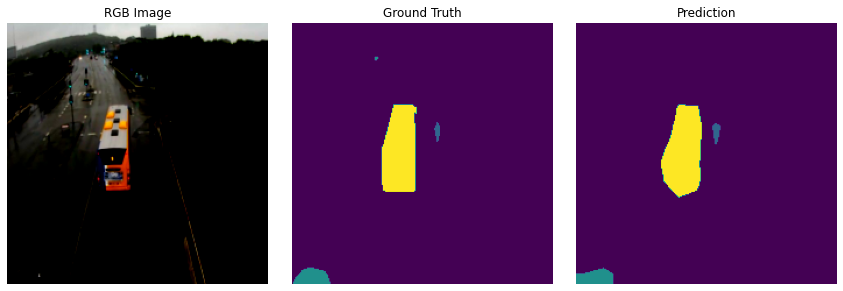

In [42]:
visualize_sample(test_dataset[281], model)
